# Telecom Customer Churn Analysis

## 03: Bivariate Analysis and Churn Drivers

### Objective

This notebook investigates relationships between customer characteristics, service usage, billing behavior, and customer churn.

The analysis focuses on:

- Examining relationships between demographic characteristics and customer behavior
- Exploring how customer tenure relates to billing, revenue, and service usage
- Investigating how service subscriptions, internet types, offers, and contracts relate to monthly charges
- Comparing customer characteristics and behaviors across different customer statuses
- Identifying patterns associated with churn that warrant further investigation

This builds on the univariate analysis to develop a deeper understanding of how customer characteristics and behaviors relate to one another, while identifying potential churn drivers for further analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [3]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Customer Profile and Behavior

##### Age and Internet
- Are older customers less likely to have internet service than young customers?
- Do older customers use less data than younger customers?

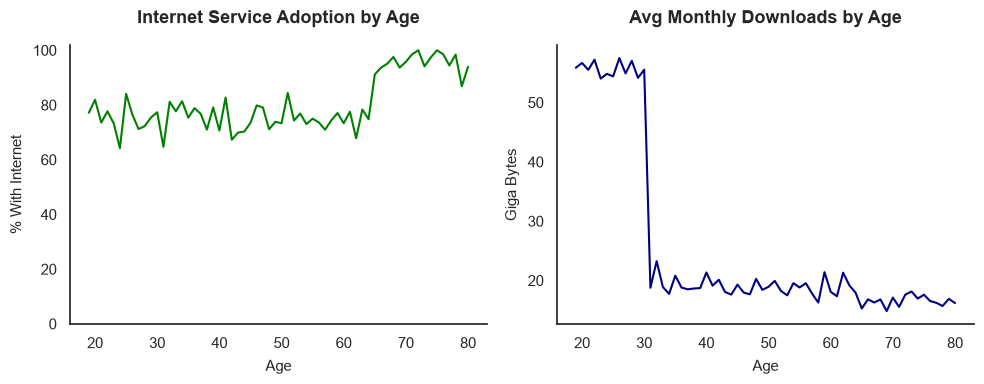

In [79]:
internet_customers = churn_df[churn_df['Internet Service'] == True]

# Calculate Download Consumption by Age
gb_by_age = (
    internet_customers.groupby('Age')['Avg Monthly GB Download'].mean()
)

# Calculate Internet Service adoption rate by Age
internet_by_age = churn_df.groupby('Age')['Internet Service'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(
    internet_by_age.index,
    internet_by_age.values,
    color='green'
)

ax1.set_title('Internet Service Adoption by Age')
ax1.set_ylabel('% With Internet')
ax1.set_xlabel('Age')
ax1.set_ylim(bottom=0)

ax2.plot(
    gb_by_age.index,
    gb_by_age.values,
    color='navy'
)

ax2.set_title('Avg Monthly Downloads by Age')
ax2.set_ylabel('Giga Bytes')
ax2.set_xlabel('Age')

plt.tight_layout();

Customers aged 65 and older have an internet service adoption rate of approximately 90–100%, compared with roughly 65–85% among younger customers. Among customers with internet service, those aged 30 and below download an average of approximately 50–55 GB per month. Average usage drops sharply around age 31 and remains at roughly 15–20 GB per month among older customers.

**Overall, even though older customers are more likely to have internet service, they use less data on average than younger subscribers.**

##### Number of Dependents and Services, Data Usage
- Are customers with dependents more likely to subscribe to core services?
- Are customers with dependents more likely to subscribe to streaming services?
- Do customers with dependents download more data per month on average?

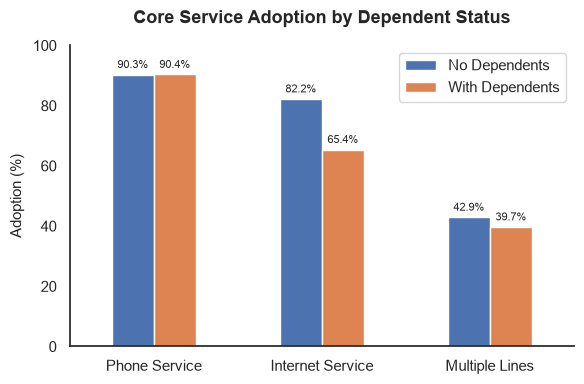

In [186]:
phone_service_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Phone Service'].mean() * 100
internet_service_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Internet Service'].mean() * 100
multiple_lines_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Multiple Lines'].mean() * 100

core_service_adoption = pd.DataFrame(
    {
        'Phone Service': phone_service_by_dependents,
        'Internet Service': internet_service_by_dependents,
        'Multiple Lines': multiple_lines_by_dependents
    }
).T

ax = core_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0
    )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=8
    )
    
ax.set_title('Core Service Adoption by Dependent Status')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=100)
ax.legend(['No Dependents', 'With Dependents'])
plt.tight_layout();

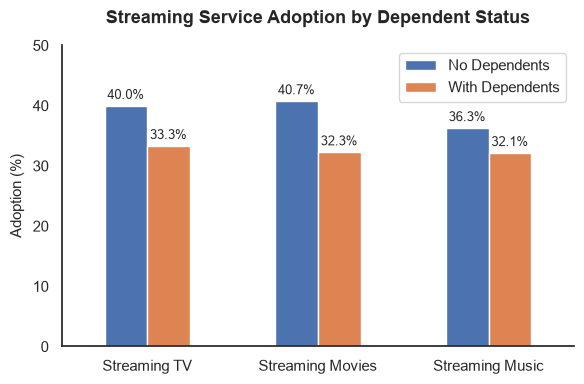

In [188]:
streaming_tv_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming TV'].mean() * 100
streaming_movies_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming Movies'].mean() * 100
streaming_music_by_dependents = churn_df.groupby(churn_df['Number of Dependents'] > 0)['Streaming Music'].mean() * 100

streaming_service_adoption = pd.DataFrame(
    {
        'Streaming TV': streaming_tv_by_dependents,
        'Streaming Movies': streaming_movies_by_dependents,
        'Streaming Music': streaming_music_by_dependents
    }
).T

ax = streaming_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0
    )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Streaming Service Adoption by Dependent Status')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=50)
ax.legend(['No Dependents', 'With Dependents'])
plt.tight_layout();


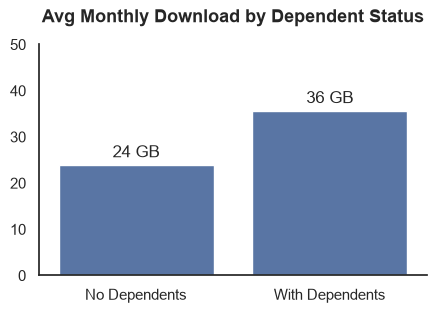

In [189]:
internet_customers = churn_df[churn_df['Internet Service']]
monthly_download_by_dependents = internet_customers.groupby(internet_customers['Number of Dependents'] > 0)['Avg Monthly GB Download'].mean()

ax = sns.barplot(
    x=monthly_download_by_dependents.index,
    y=monthly_download_by_dependents.values
)

ax.bar_label(ax.containers[0], 
             fmt='%.0f GB', 
             padding=3)

plt.title('Avg Monthly Download by Dependent Status')
plt.ylim(top=50)
plt.xlabel('')
plt.xticks([0, 1], ['No Dependents', 'With Dependents']);

Customers without dependents have an internet service adoption rate of 16.8 percentage points higher than customers with dependents. Phone service and multiple-line adoption differ by just 0.1 and 3.2 percentage points, respectively.

Customers without dependents also have higher adoption rates for all three streaming services—TV, movies, and music—by approximately 4–7 percentage points.

However, among customers with internet service, those with at least one dependent download approximately 12 GB more data per month on average than those without dependents.


##### Marital Status and Referral Behavior
Do married customers make more referrals than unmarried customers?

In [100]:
churn_df.groupby('Married')['Number of Referrals'].agg(['sum', 'mean'])

,sum,mean
Married,,
False,0,0.0
True,13747,4.040858


No unmarried customers recorded any referrals in this dataset. All recorded referrals came from married customers.

##### Gender and Avg Monthly Data Usage
Do male and female internet subscribers use different amounts of data on average?

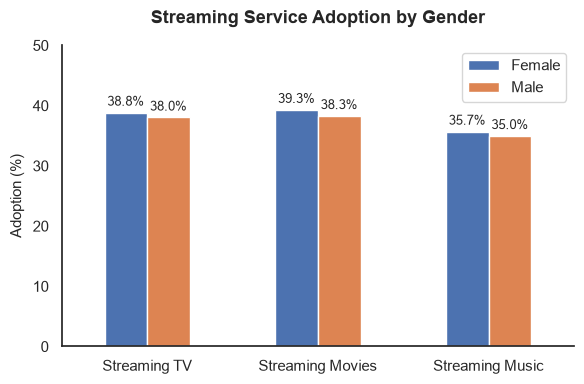

In [193]:
streaming_tv_by_gender = churn_df.groupby('Gender')['Streaming TV'].mean() * 100

streaming_movies_by_gender = churn_df.groupby('Gender')['Streaming Movies'].mean() * 100

streaming_music_by_gender = churn_df.groupby('Gender')['Streaming Music'].mean() * 100

streaming_service_adoption = pd.DataFrame(
    {
        'Streaming TV': streaming_tv_by_gender,
        'Streaming Movies': streaming_movies_by_gender,
        'Streaming Music': streaming_music_by_gender
    }
).T

ax = streaming_service_adoption.plot.bar(
    figsize=(6, 4),
    rot=0
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Streaming Service Adoption by Gender')
ax.set_ylabel('Adoption (%)')
ax.set_ylim(top=50)
ax.legend(['Female', 'Male'])

plt.tight_layout();

##### Gender and Additional Services
Does adoption of additional services differ by gender?

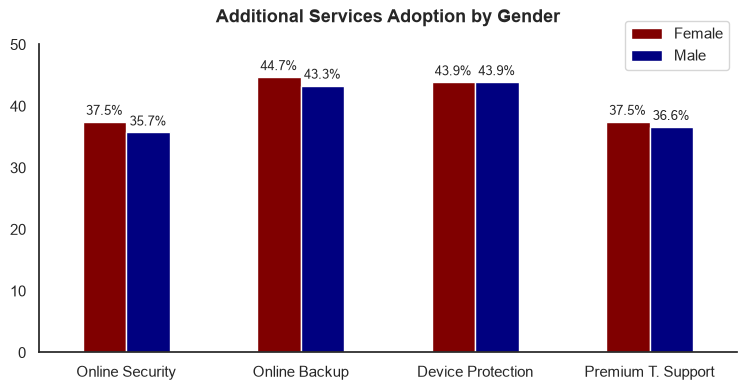

In [224]:
online_security_by_gender = internet_customers.groupby('Gender')['Online Security'].mean() * 100
online_backup_by_gender = internet_customers.groupby('Gender')['Online Backup'].mean() * 100
device_protection_plan_by_gender = internet_customers.groupby('Gender')['Device Protection Plan'].mean() * 100
premium_tech_support_by_gender = internet_customers.groupby('Gender')['Premium Tech Support'].mean() * 100

additional_services_adoption = pd.DataFrame(
    {
        'Online Security': online_security_by_gender,
        'Online Backup': online_backup_by_gender,
        'Device Protection Plan': device_protection_plan_by_gender,
        'Premium Tech Support': premium_tech_support_by_gender
    }
).T

ax = additional_services_adoption.plot.bar(
    rot=0,
    figsize=(9, 4),
    color=['maroon', 'navy']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

ax.set_title('Additional Services Adoption by Gender')
ax.set_ylim(top=50)
ax.legend(bbox_to_anchor=(1, 1.1))
ax.set_xticks([0, 1, 2, 3], 
              ['Online Security', 'Online Backup', 'Device Protection', 'Premium T. Support'])
plt.tight_layout;

Among customers with internet service, adoption of additional services shows little variation by gender, with differences of less than 2 percentage points across all four services.

### Tenure and Customer Value



### Service Usage and Billing



### Offers, Contracts, and Customer Behavior



### Customer Churn Analysis